In [71]:
library(data.table)
library(ggplot2)
library(ggpubr)
library(vegan)
library(paletteer)

# 1. original clones

mouse,clone,numCell,unique
<chr>,<chr>,<int>,<dbl>
Q25,Clone1,16891,0.3030608
C4033,Clone2,2860,0.7216783
C4007,Clone2,2850,0.1698246
C4033,Clone1,2603,0.6746062
C4033,Clone3,1951,0.8616094


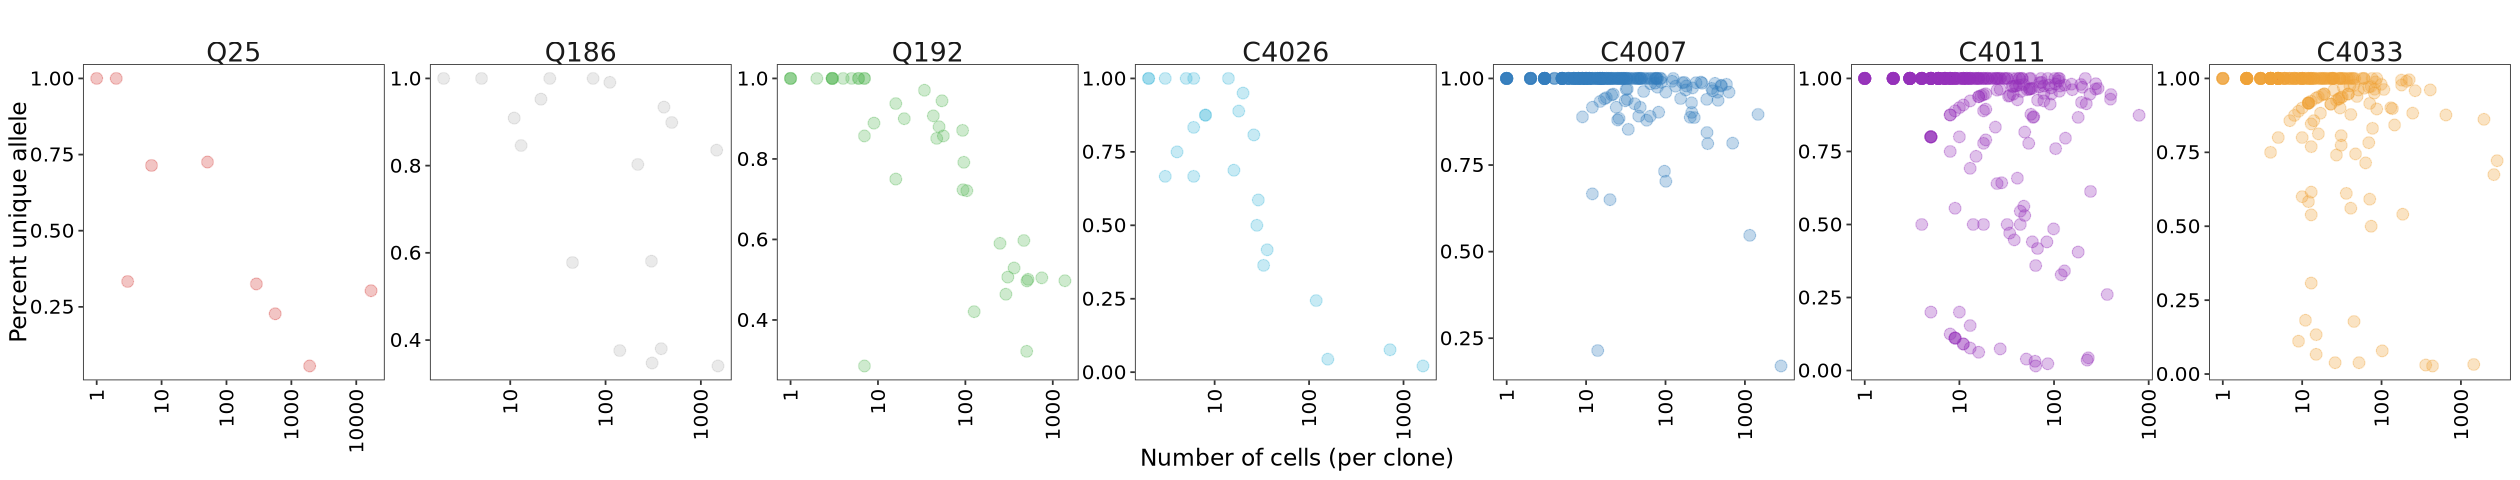

In [72]:
mice=c("Q25","Q186","Q192","C4026","C4007","C4011","C4033")
INDIR="/syn2/zhaolian/3.JiLab/results/3.PacBio/3.clones/"
setwd(INDIR)
df <- data.table()
df_stats <- data.table()
for(my.mouse in mice){
    clonelist=read.delim(paste0(my.mouse, "_clone_list.txt"),header = F)
    for(i in clonelist$V1){
        phy=read.table(paste0(INDIR,my.mouse,"/",i,".phy"),sep=" ",header=F, skip=2,colClasses = c("character","character"),col.names=c("cellBC","bi"))
        df <- rbind(df, data.table(mouse=my.mouse, clone=strsplit(i,"_")[[1]][1],numCell=nrow(phy),unique=length(unique(phy$bi))/nrow(phy)))
        df_stats <- rbind(df_stats, data.table(mouse=my.mouse, numCells=nrow(phy)))
    }
}
df <- df[order(-numCell)]
df[1:5,]

df$mouse <- factor(df$mouse, levels=mice)
options(repr.plot.width=21,repr.plot.height=4)

mycols=c('Q25'="#D43F3AFF",'Q186'="#B8B8B8FF",'Q192'="#5CB85CFF",'C4026'="#46B8DAFF",'C4007'="#357EBDFF",'C4011'="#9632B8FF",'C4033'="#EEA236FF")
ggplot(df, aes(x=numCell, y=unique, color=mouse))+geom_point(size=3, alpha=.3)+scale_x_log10() +#xlim(0,1000)+
  theme_bw()+facet_wrap(~mouse, ncol=7, scale="free")+
  theme(panel.grid =element_blank()) +
  labs(y="Percent unique allele",x="Number of cells (per clone)")+
  ggtitle("")+
    theme(panel.grid =element_blank())+
    scale_color_manual(values=mycols)+
    theme(axis.text.x = element_text(size=12, colour = "black", angle=90, vjust=0.5, hjust=1),
            axis.text.y = element_text(size=12, colour = "black"),
            axis.title.x = element_text(size = 14),
            axis.title.y = element_text(size = 14),
            strip.text = element_text(size = 16, margin = margin()),
          strip.background = element_blank(),
            legend.position="none",
            legend.title=element_text(size=12),
            legend.key.size=unit(0.7,"cm"),
            legend.text=element_text(size=10))

# 2. filtering 

In [80]:
mice=c("Q25","Q186","Q192","C4026","C4007","C4011","C4033")
INDIR="/syn2/zhaolian/3.JiLab/results/3.PacBio/3.clones/"
base_path <- "/syn2/zhaolian/3.JiLab/results/3.PacBio/4.clones_filtered"
setwd(INDIR)
df <- data.table()
for(my.mouse in mice){
    OUTDIR <- file.path(base_path, my.mouse)
    if (!dir.exists(OUTDIR)) {
      dir.create(OUTDIR, recursive = TRUE)
    }    
    dt <- data.table()
    clonelist=read.delim(paste0(my.mouse, "_clone_list.txt"),header = F)
    list_new <- data.table()
    for(i in clonelist$V1){
        phy=read.table(paste0(INDIR,my.mouse,"/",i,".phy"),sep=" ",header=F, skip=2,colClasses = c("character","character"),col.names=c("cellBC","bi"))
        numCell=nrow(phy)
        df <- as.data.table(table(phy$bi))
        df <- df[order(-N)]
        df <- df[!(df$N > 50 | df$N / nrow(phy) > 0.1), ]
        if(sum(df$N)>=50){
            phy <- phy[phy$bi %in% df$V1,]
            list_new <- rbind(list_new,data.table(clone=i,cellBefore=numCell,cellNew=nrow(phy)))
            header=data.table(cellBC="ref",bi=strrep("0", 476))
            phy <- rbind(header,phy)
            colnames(phy) <- c(as.character(nrow(phy)),"476")
            write.table(phy, file=paste0(OUTDIR, "/",i,"_filtered.phy"),sep=" ", row.names = F, quote=F)
        }
    }
    write.table(list_new, file=paste0(base_path, "/",my.mouse,"_clone_list_filtered.txt"),sep="\t", row.names = F, quote=F)
}


# 3. stats

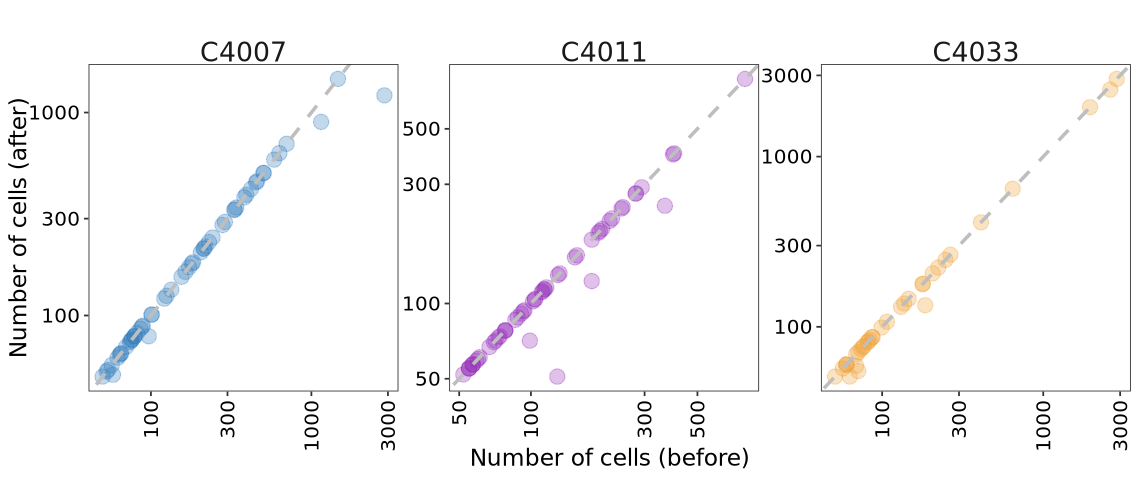

In [81]:
mice=c("Q25","Q186","Q192","C4026","C4007","C4011","C4033")
INDIR="/syn2/zhaolian/3.JiLab/results/3.PacBio/3.clones/"
base_path <- "/syn2/zhaolian/3.JiLab/results/3.PacBio/4.clones_filtered"
setwd(INDIR)
df <- data.table()
for(my.mouse in mice[5:7]){
    clonelist=read.delim(paste0(base_path, "/",my.mouse,"_clone_list_filtered.txt"),header = T)
    clonelist$mouse=my.mouse
    df <- rbind(df,clonelist)
}

df$mouse <- factor(df$mouse, levels=mice)
options(repr.plot.width=9.5,repr.plot.height=4)

mycols=c('Q25'="#D43F3AFF",'Q186'="#EEA236FF",'Q192'="#5CB85CFF",'C4026'="#46B8DAFF",'C4007'="#357EBDFF",'C4011'="#9632B8FF",'C4033'="#EEA236FF")
ggplot(df, aes(x=cellBefore, y=cellNew, color=mouse))+geom_point(size=4,alpha=0.3)+scale_x_log10() +scale_y_log10() +
    geom_abline(intercept = 0, slope = 1,color = "grey", linetype = "dashed", size = 1) +  
    theme_bw()+facet_wrap(~mouse, ncol=3, scale="free")+
    theme(panel.grid =element_blank()) +
    labs(x="Number of cells (before)",y="Number of cells (after)")+
    ggtitle("")+
    theme(panel.grid =element_blank())+
    scale_color_manual(values=mycols)+
    theme(axis.text.x = element_text(size=12, colour = "black", angle=90, vjust=0.5, hjust=1),
            axis.text.y = element_text(size=12, colour = "black"),
            axis.title.x = element_text(size = 14),
            axis.title.y = element_text(size = 14),
            strip.text = element_text(size = 16, margin = margin()),
          strip.background = element_blank(),
            legend.position="none",
            legend.title=element_text(size=12),
            legend.key.size=unit(0.7,"cm"),
            legend.text=element_text(size=10))

